# Data Quality - preprocessing
Limpieza de datos

Dataset: netflix-shows

## Dataset: netflix-shows

In [ ]:
import pandas as pd
import numpy as np

#Librerías para visualizaciones o gráficas
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None #silence

### Exploración de datos

In [ ]:
df = pd.read_csv('https://gitlab.com/dcardona2/dataanalytics/-/raw/main/Dataset/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [ ]:
print(df.shape)
print(df.dtypes)

(6234, 12)
show_id          int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


Selección de columnas numéricas

In [ ]:
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)

['show_id' 'release_year']


Selección de columnas no numéricas

In [ ]:
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

['type' 'title' 'director' 'cast' 'country' 'date_added' 'rating'
 'duration' 'listed_in' 'description']


El dataset tiene 6234 registros y 12 atributos, de los cuales 2 son numéricas y 10 son no numéricas.

### Datos Faltantes

#### Técnica #1: mapa de calor de los datos faltantes

<Axes: >

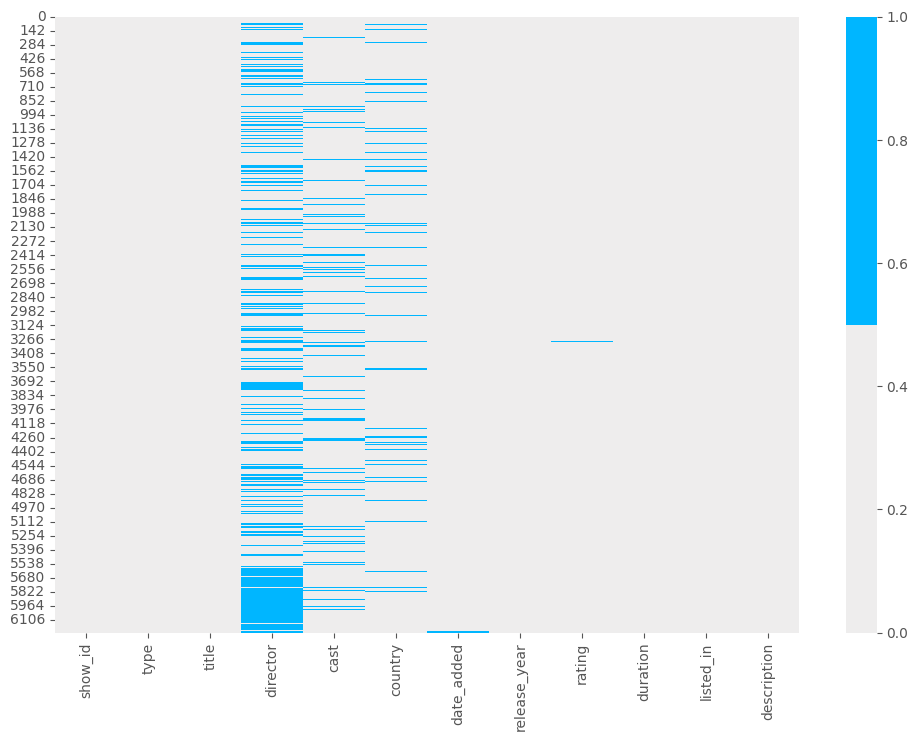

In [ ]:
cols = df.columns[:12]
colours = ['#EEEDED', '#00B6FF']
sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colours))

En la parte azul es donde están los faltantes

#### Técnica #2: Lista de porcentaje de datos faltantes¶

In [ ]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    if (pct_missing > 0):
        #print(pct_missing)
        print('{} - {}%'.format(col, round(pct_missing*100)))

director - 32%
cast - 9%
country - 8%
date_added - 0%
rating - 0%


El dataframe tiene 5 columnas con missings, el porcentaje mayor es de 32% y hay dos que tienden a 0 por eso no se alcanzan casi a percibir.

#### Técnica #3: Gráfico de columnas de datos faltantes

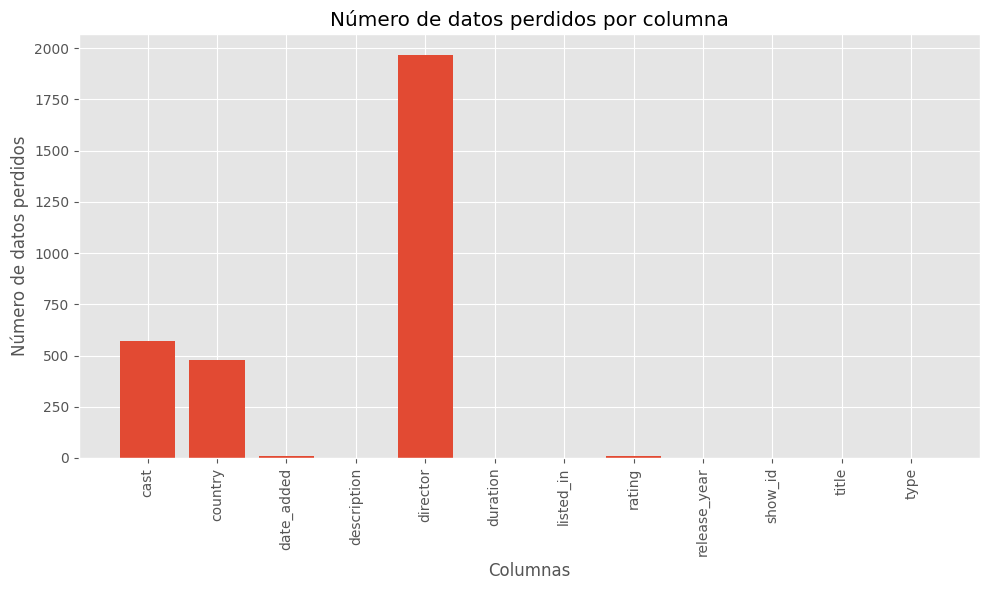

In [ ]:
import matplotlib.pyplot as plt
missing_data = df.isnull().sum().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(missing_data.index, missing_data.values)
plt.xlabel('Columnas')
plt.ylabel('Número de datos perdidos')
plt.title('Número de datos perdidos por columna')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


created missing indicator for: director
created missing indicator for: cast
created missing indicator for: country
created missing indicator for: date_added
created missing indicator for: rating


<Axes: xlabel='num_missing'>

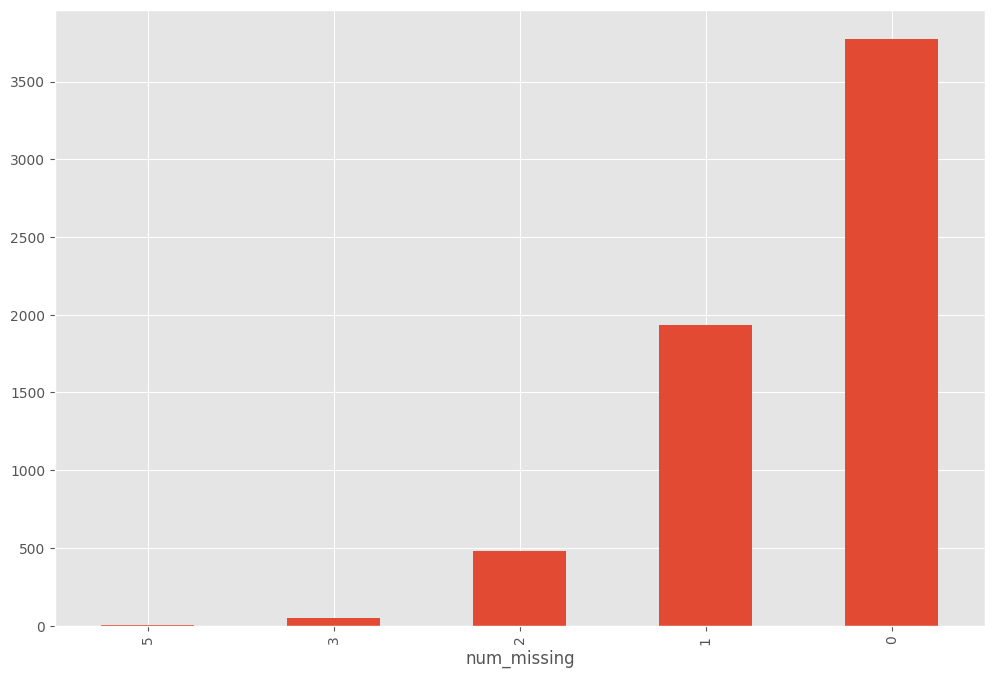

In [ ]:
for col in df.columns:
    missing = df[col].isnull()
    num_missing = np.sum(missing)

    if num_missing > 0:
        print('created missing indicator for: {}'.format(col))
        df['{}_ismissing'.format(col)] = missing


ismissing_cols = [col for col in df.columns if 'ismissing' in col]
df['num_missing'] = df[ismissing_cols].sum(axis=1)

df['num_missing'].value_counts().sort_values(ascending=True).plot.bar(x='index', y='num_missing')

La columna director es la que tiene más faltantes

### Valores Atípicos - Outliers

#### Técnica #1: Histograma y Box Plot

Histograma de release_year

<Axes: >

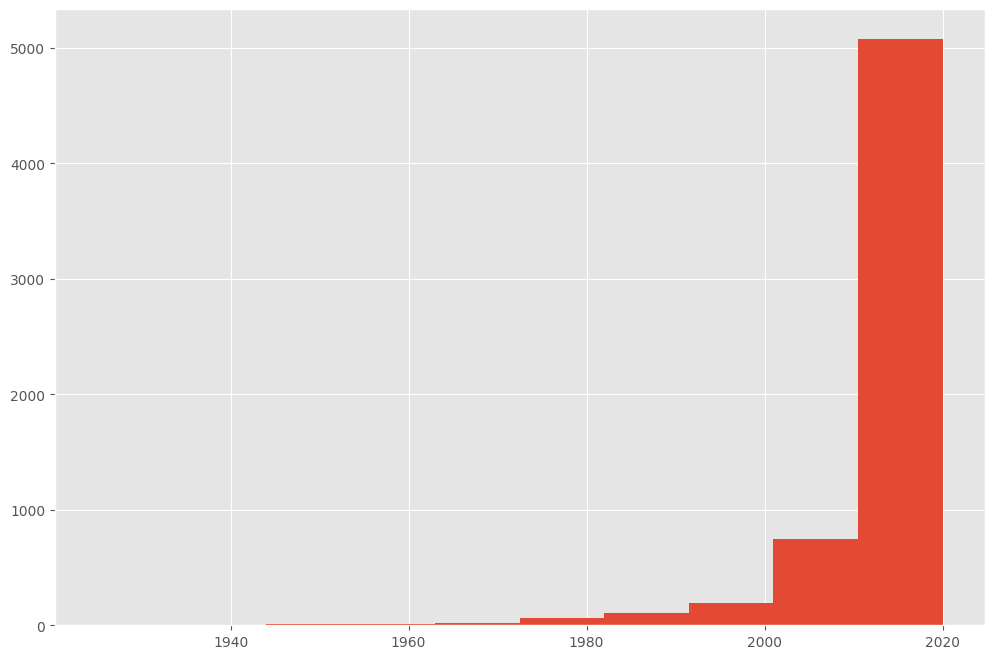

In [ ]:
df['release_year'].hist()

la distrución de release_year está cargada a los últimos años

<Axes: >

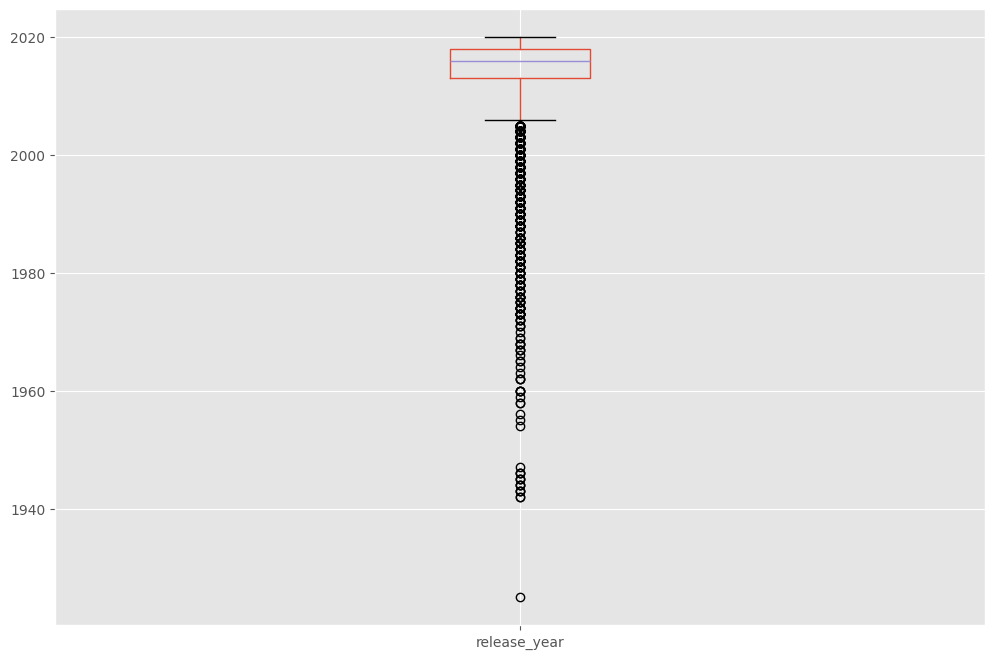

In [ ]:
df.boxplot(column=['release_year'])

Probablemente haya un outlier pues se ve un dato solito antes de 1940.

#### Técnica #2: Estadística descriptiva

In [ ]:
df['release_year'].describe()

,release_year
count,6234.00000
mean,2013.35932
std,8.81162
min,1925.00000
25%,2013.00000
50%,2016.00000
75%,2018.00000
max,2020.00000


In [ ]:
df.describe()

,show_id,release_year,num_missing
count,6.234000e+03,6234.00000,6234.000000
mean,7.670368e+07,2013.35932,0.487007
std,1.094296e+07,8.81162,0.671848
min,2.477470e+05,1925.00000,0.000000
25%,8.003580e+07,2013.00000,0.000000
50%,8.016337e+07,2016.00000,0.000000
75%,8.024489e+07,2018.00000,1.000000
max,8.123573e+07,2020.00000,5.000000


In [ ]:
df_non_numeric.describe()

,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,6234,6234,4265,5664,5758,6223,6224,6234,6234,6234
unique,2,6172,3301,5469,554,1524,14,201,461,6226
top,Movie,The Silence,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,A surly septuagenarian gets another chance at ...
freq,4265,3,18,18,2032,122,2027,1321,299,3


la estadística descriptiva indica que 1925 es el outlier que habíamos visto en el boxplot.

#### Técnica #3: Gráfico de barras

Esta técnica funciona para variables categóricas, por lo que usaremos la variable type

<Axes: xlabel='type'>

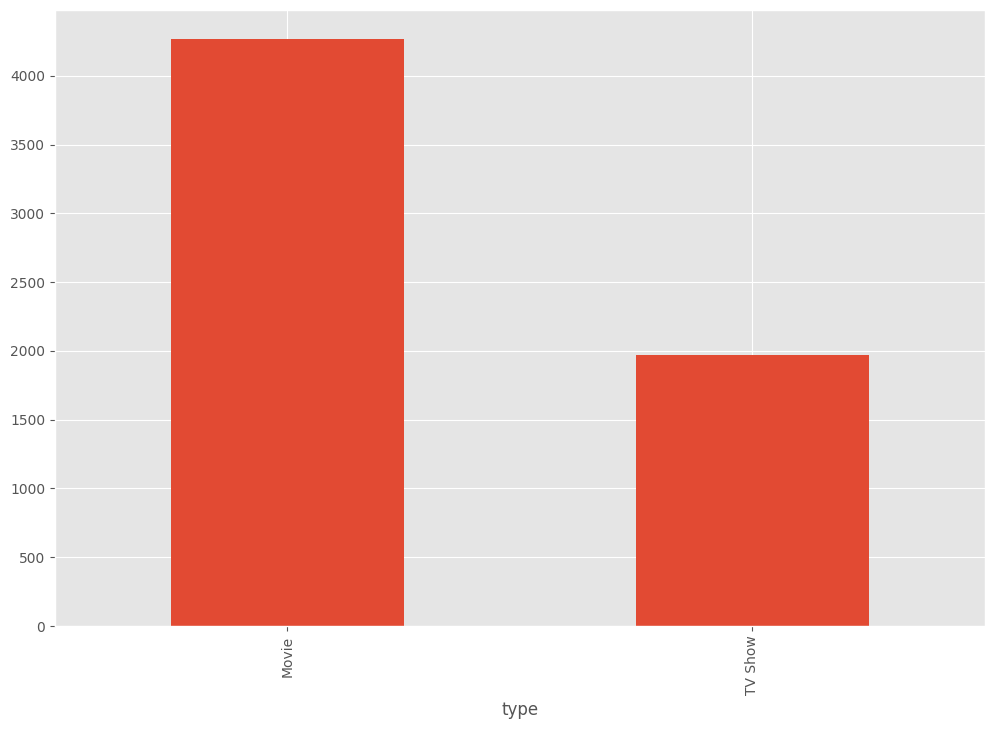

In [ ]:
df['type'].value_counts().plot.bar()

### Datos innecesarios

¿Cómo descubrir datos innecesarios?

#### Tipo innecesario #1: Desinformativo / Repetitivo


Filas con más del 95% de filas que tienen el mismo valor.

In [ ]:
num_rows = len(df.index)
low_information_cols = []

for col in df.columns:
    cnts = df[col].value_counts(dropna=False)
    top_pct = (cnts/num_rows).iloc[0]

    if top_pct > 0.95:
        low_information_cols.append(col)
        print('{0}: {1:.5f}%'.format(col, top_pct*100))
        print(cnts)
        print()

date_added_ismissing: 99.82355%
date_added_ismissing
False    6223
True       11
Name: count, dtype: int64

rating_ismissing: 99.83959%
rating_ismissing
False    6224
True       10
Name: count, dtype: int64



No hay columnas repetitivas el dataset original. Las que aparecen fueron las columnas que se adicionaron para visualización de datos perdidos

#### Tipo innecesario #2: Irrelevante
Se pueden tomar como irrelevantes los datos con más de 98% en missings porque no nos aportan información.

Para este dataset no hay atributos con pérdida de datos superior al 98%

In [ ]:

#key = ['director']

In [ ]:
#for i in range(len(key)):
#    df = df.drop(key[i], axis=1)

In [ ]:
#df.head()

#### Tipo innecesario #3: Duplicados

######                       Duplicados tipo #1: todas las características

In [ ]:
# drop () labels=single label or list-like. Index or column labels to drop. A tuple will be used as a single label and not treated as a list-like.
# Labels= Default value is none. It's mean drop rows after checked all columns
# axis: {0 or ‘index’, 1 or ‘columns’}, default 0
# .drop_duplicates() = Return DataFrame with duplicate rows removed.

df_dedupped = df.drop('show_id', axis=1).drop_duplicates()


print(df.shape)
print(df_dedupped.shape)

(6234, 18)
(6233, 17)


######  Duplicados tipo #2: características claves

Tomamos las primeras 5 características de los registros como clave

In [ ]:
#fillna: Fill NA/NaN values using the specified method. valuescalar, dict, Series, or DataFrame Value to use to fill holes (e.g. 0), alternately a dict/Series/DataFrame of values specifying which value to use for each index (for a Series) or column (for a DataFrame).
key = ['type', 'title', 'director', 'country']

df.fillna(-999).groupby(key)['show_id'].count().sort_values(ascending=False).head(20)

type     title                                     director                         country                                       
Movie    Sarkar                                    A.R. Murugadoss                  India                                             2
         Frank and Cindy                           G.J. Echternkamp                 United States                                     2
TV Show  Charmed                                   -999                             United States                                     2
         Kakegurui                                 -999                             Japan                                             2
Movie    The Silence                               Gajendra Ahire                   India                                             2
TV Show  Top Boy                                   -999                             United Kingdom                                    2
Movie    Who Would You Take to a Deserted Island?  Jota Linares                     Spain                                             1
         Whitney Cummings: Money Shot              John Fortenberry                 United States                                     1
         Whitney Cummings: Can I Touch It?         Marcus Raboy                     -999                                              1
         White Island                              Benjamin Turner                  United Kingdom                                    1
         White Girl                                Elizabeth Wood                   United States                                     1
         White Fang                                Alexandre Espigares              France, Luxembourg, United States                 1
         White Christmas                           Michael Curtiz                   United States                                     1
         White Chamber                             Paul Raschid                     United Kingdom                                    1
         Who the F**k Is That Guy?                 Drew Stone                       United States                                     1
         While We're Young                         Noah Baumbach                    United States                                     1
         Where's the Money                         Scott Zabielski                  United States                                     1
         Where the Money Is                        Marek Kanievska                  Germany, United States, United Kingdom, Canada    1
         When We First Met                         Ari Sandel                       United States                                     1
         When Two Worlds Collide                   Heidi Brandenburg, Mathew Orzel  Peru, United States, United Kingdom               1
Name: show_id, dtype: int64

In [ ]:
df_dedupped2 = df.drop_duplicates(subset=key)

print(df.shape)
print(df_dedupped2.shape)

(6234, 18)
(6228, 18)


No hubo ninguna columna duplicada por características clave

### Datos inconsistentes

In [ ]:
# Showing different values for "country" column
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

#### Tipo inconsistente #1: Capitalización

In [ ]:
df['title'].value_counts(dropna=False)

,count
title,
The Silence,3
Love,3
Limitless,3
Tunnel,3
Oh My Ghost,3
...,...
I Don't Know How She Does It,1
"Drugs, Inc.",1
The Most Hated Woman in America,1


In [ ]:
df['title_upper'] = df['title'].str.upper()
df['title_upper'].value_counts(dropna=False)

,count
title_upper,
THE SILENCE,3
LIMITLESS,3
OH MY GHOST,3
LOVE,3
TUNNEL,3
...,...
OVERSIZE COPS,1
I DON'T KNOW HOW SHE DOES IT,1
"DRUGS, INC.",1


#### Tipo inconsistente #2: Formatos

In [ ]:
df.date_added.value_counts()

,count
date_added,
"January 1, 2020",122
"November 1, 2019",94
"March 1, 2018",78
"December 31, 2019",74
"October 1, 2018",72
...,...
"April 27, 2018",1
"April 28, 2019",1
"April 29, 2019",1


In [ ]:
df.date_added.describe()

,date_added
count,6223
unique,1524
top,"January 1, 2020"
freq,122


In [ ]:
df['date_added_dt'] = pd.to_datetime(df['date_added'], errors="coerce")
df['year'] = df['date_added_dt'].dt.year
df['month'] = df['date_added_dt'].dt.month
df['weekday'] = df['date_added_dt'].dt.weekday

print(df['year'].value_counts(dropna=False))
print()
print(df['month'].value_counts(dropna=False))

year
2019.0    2057
2018.0    1629
2017.0    1184
NaN        651
2016.0     412
2020.0     174
2015.0      74
2014.0      19
2011.0      13
2013.0       9
2012.0       7
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

month
NaN     651
12.0    638
10.0    580
1.0     563
11.0    544
3.0     504
8.0     454
9.0     420
7.0     413
4.0     406
5.0     380
2.0     342
6.0     339
Name: count, dtype: int64


#### Tipo inconsistente #3: Valores categóricos

Distancia Edith para géneros:

In [ ]:
df.listed_in.tolist()

['Children & Family Movies, Comedies',
 'Stand-Up Comedy',
 "Kids' TV",
 "Kids' TV",
 'Comedies',
 'Crime TV Shows, International TV Shows, Spanish-Language TV Shows',
 'International Movies, Sci-Fi & Fantasy, Thrillers',
 'Stand-Up Comedy',
 'Docuseries, Science & Nature TV',
 'Action & Adventure, Thrillers',
 'Stand-Up Comedy',
 'Action & Adventure, Dramas, International Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Children & Family Movies',
 'Cult Movies, Dramas, Independent Movies',
 'Comedies, Independent Movies, Romantic Movies',
 'Action & Adventure, Comedies, International Movies',
 'Documentaries',
 'Horror Movies, Thrillers',
 'Dramas, Independent Movies',
 'Dramas, Independent Movies, Romantic Movies',
 'International TV Shows, Romantic TV Shows, TV Comedies',
 'Documentaries',
 'Docuseries',
 'Horror Movies, International Movies',
 'Chi

para Children & Family Movies y Stand-Up Comedy

In [ ]:
from nltk.metrics import edit_distance

df['listed_in_distance_c'] = df['listed_in'].map(lambda x: edit_distance(x, 'Children & Family Movies'))
df['listed_in_distance_s'] = df['listed_in'].map(lambda x: edit_distance(x, 'Stand-Up Comedy'))
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_ismissing,rating_ismissing,num_missing,title_upper,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,False,False,0,NORM OF THE NORTH: KING SIZED ADVENTURE,2019-09-09,2019.0,9.0,0.0,10,27
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,False,False,1,JANDINO: WHATEVER IT TAKES,2016-09-09,2016.0,9.0,4.0,20,0
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,False,False,1,TRANSFORMERS PRIME,2018-09-08,2018.0,9.0,5.0,21,13
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,False,False,1,TRANSFORMERS: ROBOTS IN DISGUISE,2018-09-08,2018.0,9.0,5.0,21,13
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,False,False,0,#REALITYHIGH,2017-09-08,2017.0,9.0,4.0,19,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6229,80000063,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,...,True,False,2,RED VS. BLUE,NaT,NaN,NaN,NaN,44,45
6230,70286564,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,...,True,False,2,MARON,NaT,NaN,NaN,NaN,19,11
6231,80116008,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,NaN,NaN,NaN,2016,NaN,60 min,...,True,True,5,LITTLE BABY BUM: NURSERY RHYME FRIENDS,NaT,NaN,NaN,NaN,18,14
6232,70281022,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,...,True,False,2,A YOUNG DOCTOR'S NOTEBOOK AND OTHER STORIES,NaT,NaN,NaN,NaN,33,33


In [ ]:
msk = df['listed_in_distance_c'] <= 2
df.loc[msk, 'listed_in'] = 'Children & Family Movies'

msk = df['listed_in_distance_s'] <= 2
df.loc[msk, 'listed_in'] = 'Stand-Up Comedy'

df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_ismissing,rating_ismissing,num_missing,title_upper,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,False,False,0,NORM OF THE NORTH: KING SIZED ADVENTURE,2019-09-09,2019.0,9.0,0.0,10,27
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,False,False,1,JANDINO: WHATEVER IT TAKES,2016-09-09,2016.0,9.0,4.0,20,0
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,False,False,1,TRANSFORMERS PRIME,2018-09-08,2018.0,9.0,5.0,21,13
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,False,False,1,TRANSFORMERS: ROBOTS IN DISGUISE,2018-09-08,2018.0,9.0,5.0,21,13
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,False,False,0,#REALITYHIGH,2017-09-08,2017.0,9.0,4.0,19,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6229,80000063,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,...,True,False,2,RED VS. BLUE,NaT,NaN,NaN,NaN,44,45
6230,70286564,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,...,True,False,2,MARON,NaT,NaN,NaN,NaN,19,11
6231,80116008,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,NaN,NaN,NaN,2016,NaN,60 min,...,True,True,5,LITTLE BABY BUM: NURSERY RHYME FRIENDS,NaT,NaN,NaN,NaN,18,14
6232,70281022,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,...,True,False,2,A YOUNG DOCTOR'S NOTEBOOK AND OTHER STORIES,NaT,NaN,NaN,NaN,33,33


#### Tipo inconsistente #4: Direcciones

In [ ]:
df['country_std'] = df['country'].str.lower()
df['country_std'] = df['country_std'].str.strip() # remove leading and trailing whitespace.
df['country_std'] = df['country_std'].str.replace('\\.', '') # remove period.
df['country_std'] = df['country_std'].str.replace('\\bstreet\\b', 'st') # replace street with st.
df['country_std'] = df['country_std'].str.replace('\\bapartment\\b', 'apt') # replace apartment with apt.
df['country_std'] = df['country_std'].str.replace('\\bav\\b', 'ave') # replace apartment with apt.
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,rating_ismissing,num_missing,title_upper,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,False,0,NORM OF THE NORTH: KING SIZED ADVENTURE,2019-09-09,2019.0,9.0,0.0,10,27,"united states, india, south korea, china"
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,False,1,JANDINO: WHATEVER IT TAKES,2016-09-09,2016.0,9.0,4.0,20,0,united kingdom
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,False,1,TRANSFORMERS PRIME,2018-09-08,2018.0,9.0,5.0,21,13,united states
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,False,1,TRANSFORMERS: ROBOTS IN DISGUISE,2018-09-08,2018.0,9.0,5.0,21,13,united states
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,False,0,#REALITYHIGH,2017-09-08,2017.0,9.0,4.0,19,12,united states


#### Tipo inconsistente #5: Datos mezclados (Números y Texto)

Transformar la 'duration' del registro de la producción separando el número del texto, se crea un nuevo atributo duration_num que tendrá el atributo numérico y el atributo duration_unit que tendrá el texto: Minutos (min), Temporadas (season), etc.

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract('([a-zA-Z]+)')

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1723337166.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,title_upper,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,NORM OF THE NORTH: KING SIZED ADVENTURE,2019-09-09,2019.0,9.0,0.0,10,27,"united states, india, south korea, china",90.0,min
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,JANDINO: WHATEVER IT TAKES,2016-09-09,2016.0,9.0,4.0,20,0,united kingdom,94.0,min
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,TRANSFORMERS PRIME,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,TRANSFORMERS: ROBOTS IN DISGUISE,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,#REALITYHIGH,2017-09-08,2017.0,9.0,4.0,19,12,united states,99.0,min


 Identificación y Eliminación de Datos Innecesarios

# Desafío

Take the next dataset raw_data = pd.read_csv(r'/kaggle/input/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv')

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe.

**Column Descriptions** :


| Column Name   |    Description	    |   Example Values |

1. Transaction ID	Unique identifier for each transaction. Always present and unique.	TXN_1234567

2. Item	Name of the purchased item. May contain missing or invalid values such as "ERROR".	Coffee, Sandwich

3.  Quantity	Number of items purchased. May include missing or invalid values.	1, 3, UNKNOWN

4. Price Per Unit	Cost of a single unit of the item. May contain missing or invalid values.	2.00, 4.00

5. Total Spent	Total transaction amount calculated as Quantity × Price Per Unit.	8.00, 12.00

6. Payment Method	Method used for payment. May include missing or invalid entries like None or "UNKNOWN".	Cash, Credit Card

7. Location	Where the transaction occurred. May contain missing or invalid values.	In-store, Takeaway

8. Transaction Date	Date when the transaction happened. May include missing or incorrect values.	2023-01-01



Ponga en práctica todo lo que hemos aprendido hasta acá:



*   Utilice dos técnicas para determinar los datos faltantes
*   Identifique valores atípicos (outliers) en el conjunto de datos
*   Establezca si hay valores innecesarios, irrelevantes o duplicados
*   Realice la transformación de datos:
    *  Remplace los valores 'ERROR', 'UNKNOWN' por datos Null
    *  Calcule los valores perdidos (null) para las tres columnas de Quantity, Price Per Unit, Total Spent. Utilice la fórmula `Total Spent = Quantity * Price Per Unit`. La fórmula `Quantity = Total Spent / 'Price Per Unit'` Haga lo mismo para *`Price Per Unit`*

    *  Para columnas como Payment Method, Location missing completar values perdidos con una imputación de una medida de tendencia central y otra usando método aleatorio simple. Para la columna `Transaction Date` impute los valores perdidos usando el método de interpolación lineal (tip: utilice el método `to_datetime` de pandas y del dataframe utilice `interpolate(method = 'linear')`.

> Agregar bloque entrecomillado







# Preprocessing
Dataset: netflix-shows

In [ ]:
import pandas as pd
import numpy as np

#dfp = pd.read_csv('https://gitlab.com/dcardona2/dataanalytics/-/raw/main/Dataset/netflix_titles.csv')
dfp = df.copy()
dfp.head(8)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,title_upper,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,NORM OF THE NORTH: KING SIZED ADVENTURE,2019-09-09,2019.0,9.0,0.0,10,27,"united states, india, south korea, china",90.0,min
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,JANDINO: WHATEVER IT TAKES,2016-09-09,2016.0,9.0,4.0,20,0,united kingdom,94.0,min
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,TRANSFORMERS PRIME,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,TRANSFORMERS: ROBOTS IN DISGUISE,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,#REALITYHIGH,2017-09-08,2017.0,9.0,4.0,19,12,united states,99.0,min
5,80163890,TV Show,Apaches,NaN,"Alberto Ammann, Eloy Azorín, Verónica Echegui,...",Spain,"September 8, 2017",2016,TV-MA,1 Season,...,APACHES,2017-09-08,2017.0,9.0,4.0,53,58,spain,1.0,Season
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,...,AUTOMATA,2017-09-08,2017.0,9.0,4.0,36,43,"bulgaria, united states, spain, canada",110.0,min
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,...,FABRIZIO COPANO: SOLO PIENSO EN MI,2017-09-08,2017.0,9.0,4.0,20,0,chile,60.0,min


## Agregación

Se crea un nuevo atributo (columna) y se asigna valores correspondientes, que agregan los datos de meses de 12 a solo 2 -Semestre 1 y Semestre 2

In [ ]:
# Agreggation
# function to assign semester based on month
def get_semester(month):
    if 1 <= month <= 6:
        return 1
    elif 7 <= month <= 12:
        return 2
    else:
        return np.nan # Handle cases where month is NaN

dfp['semester'] = dfp['month'].apply(get_semester)
dfp.head(10)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,semester
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,...,2019-09-09,2019.0,9.0,0.0,10,27,"united states, india, south korea, china",90.0,min,2.0
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,...,2016-09-09,2016.0,9.0,4.0,20,0,united kingdom,94.0,min,2.0
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,...,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season,2.0
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,...,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season,2.0
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,...,2017-09-08,2017.0,9.0,4.0,19,12,united states,99.0,min,2.0
5,80163890,TV Show,Apaches,NaN,"Alberto Ammann, Eloy Azorín, Verónica Echegui,...",Spain,"September 8, 2017",2016,TV-MA,1 Season,...,2017-09-08,2017.0,9.0,4.0,53,58,spain,1.0,Season,2.0
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,...,2017-09-08,2017.0,9.0,4.0,36,43,"bulgaria, united states, spain, canada",110.0,min,2.0
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,...,2017-09-08,2017.0,9.0,4.0,20,0,chile,60.0,min,2.0
8,80117902,TV Show,Fire Chasers,NaN,NaN,United States,"September 8, 2017",2017,TV-MA,1 Season,...,2017-09-08,2017.0,9.0,4.0,26,27,united states,1.0,Season,2.0
9,70304990,Movie,Good People,Henrik Ruben Genz,"James Franco, Kate Hudson, Tom Wilkinson, Omar...","United States, United Kingdom, Denmark, Sweden","September 8, 2017",2014,R,90 min,...,2017-09-08,2017.0,9.0,4.0,23,24,"united states, united kingdom, denmark, sweden",90.0,min,2.0


In [ ]:
#Conteo de instancias por semestre (Atributo adicionado)
dfp['semester'].value_counts()

,count
semester,
2.0,3049
1.0,2534


## Muestreo (Sampling)


### Muestreo Aleatorio Simple (Simple random sampling)

In [ ]:
# Muestreo Aleatorio Simple (Simple random sampling)
# frac=1 means return all rows in random order
# frac=0.5 means return 50% of rows in random order
# random state for reproducibility. random_state=<integer_number> is 42 a fixed number commonly used in docs and test to obtain allways the same outside or result. The number could be anything
dfp_sample = dfp.sample(frac=0.5, random_state=42)

print('instancias y atributos: ',dfp_sample.shape)
dfp_sample.head()

instancias y atributos:  (3117, 29)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,semester
599,81025317,TV Show,License to Drill: Louisiana,NaN,NaN,Canada,"October 2, 2019",2014,TV-PG,1 Season,...,2019-10-02,2019.0,10.0,2.0,19,13,canada,1.0,Season,2.0
5818,80184422,TV Show,Ha Unlimited,NaN,"Tuck Boriboon, Ball Chernyim, Na’Kom Chuanchuen",NaN,"May 11, 2018",2016,TV-14,2 Seasons,...,NaT,NaN,NaN,NaN,27,26,NaN,2.0,Seasons,NaN
5386,80232914,TV Show,The Chalet,NaN,"Chloé Lambert, Philippe Dusseau, Emilie de Pre...",France,"April 17, 2018",2018,TV-MA,1 Season,...,2018-04-17,2018.0,4.0,1.0,39,43,france,1.0,Season,1.0
401,80106137,Movie,Bon Bini Holland,Jelle de Jonge,"Jandino Asporaat, Liliana de Vries, Teun Kuilb...",Netherlands,"September 1, 2016",2015,TV-14,88 min,...,2016-09-01,2016.0,9.0,3.0,17,26,netherlands,88.0,min,2.0
1268,81076114,Movie,House Arrest,"Shashanka Ghosh, Samit Basu","Ali Fazal, Shriya Pilgaonkar, Jim Sarbh, Barkh...",India,"November 15, 2019",2019,TV-14,105 min,...,2019-11-15,2019.0,11.0,4.0,34,45,india,105.0,min,2.0


###Muestreo estratificado (Stratified sampling)

Split the data into several partitions; then draw random samples from each partition


In [ ]:
#Conteo de instancias por type (tipo de programas)
dfp['type'].value_counts()

,count
type,
Movie,4265
TV Show,1969


In [ ]:
# Stratified sampling by 'type'
# frac specifies the fraction of each stratum to sample
dfp_stratified_sample = dfp.groupby('type').sample(frac=0.5, random_state=42)
print('instancias y atributos: ',dfp_stratified_sample.shape)
dfp_stratified_sample.head()

instancias y atributos:  (3116, 29)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,semester
3676,70297799,Movie,Nymphomaniac: Volume 1,Lars von Trier,"Charlotte Gainsbourg, Stellan Skarsgård, Stacy...","Denmark, Germany, Belgium, United Kingdom, France","January 1, 2018",2013,NR,117 min,...,2018-01-01,2018.0,1.0,0.0,34,42,"denmark, germany, belgium, united kingdom, france",117.0,min,1.0
4609,81001121,Movie,Gehenna: Where Death Lives,Hiroshi Katagiri,"Eva Swan, Simon Phillips, Justin Gordon, Doug ...","Japan, United States","December 10, 2018",2016,TV-MA,107 min,...,2018-12-10,2018.0,12.0,0.0,21,22,"japan, united states",107.0,min,2.0
421,81183570,Movie,Home Is Where the Killer Is,Kaila York,"Stacy Haiduk, Kelly Kruger, Christopher Sean, ...",United States,"October 9, 2019",2019,TV-14,87 min,...,2019-10-09,2019.0,10.0,2.0,20,15,united states,87.0,min,2.0
2350,80238297,Movie,Kaakan,Kranti Redkar,"Jitendra Joshi, Urmila Kanitkar, Ashutosh Gaik...",India,"March 1, 2018",2015,TV-14,132 min,...,2018-03-01,2018.0,3.0,3.0,33,39,india,132.0,min,1.0
5487,70110558,Movie,Sherlock Holmes,Guy Ritchie,"Robert Downey Jr., Jude Law, Rachel McAdams, M...","United States, Germany, United Kingdom","April 1, 2019",2009,PG-13,128 min,...,2019-04-01,2019.0,4.0,0.0,21,19,"united states, germany, united kingdom",128.0,min,1.0


In [ ]:
dfp_stratified_sample.groupby('type').count()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,...,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,semester
type,,,,,,,,,,,,,,,,,,,,,
Movie,2132,2132,2063,1957,2036,2131,2132,2128,2132,2132,...,2131,2131,2131,2131,2132,2132,2036,2132,2132,2131
TV Show,984,984,56,875,842,980,984,983,984,984,...,657,657,657,657,984,984,842,984,984,657


In [ ]:
#Conteo de instancias por type (tipo de programas) en el dataframe muestreado
dfp_stratified_sample['type'].value_counts()

,count
type,
Movie,2132
TV Show,984


## Discretización

Unsupervised Discretization. Un tipo es separar en intervalos iguales de anchos o bins

In [ ]:
dfp['duration_num'].describe()

,duration_num
count,6234.000000
mean,68.362047
std,50.862874
min,1.000000
25%,2.000000
50%,87.000000
75%,105.000000
max,312.000000


In [ ]:
# Discretization Equal interval width approach used to obtain 4 values.
#The pandas.cut() function is used to divide or group numerical data into different categories (called bins).
# is divide to bin continuous numerical data into discrete intervals or categories. This function is particularly useful when transforming a continuous variable into a categorical one for analysis or visualization.

#Binning: pd.cut() divides the range of numerical data into specified bins. These bins can be defined by:
#Number of bins: Providing an integer for the bins argument will automatically create that many equally spaced bins.
#Custom bin edges: Providing a sequence (list or array) of numerical values for bins allows for defining custom, non-uniform bin boundaries.

#dfp['duration_num_discretized'] = pd.cut(dfp['duration_num'], bins=4, labels=False)
dfp['duration_num_discretized'] = pd.cut(dfp['duration_num'], bins=4, labels=['1 to 79', '80 to 159', '160 to 239', '240 to 312']) # bins with labels
dfp[['duration_num', 'duration_num_discretized']].head()

,duration_num,duration_num_discretized
0,90.0,80 to 159
1,94.0,80 to 159
2,1.0,1 to 79
3,1.0,1 to 79
4,99.0,80 to 159


In [ ]:
dfp['duration_num_discretized'].value_counts()

,count
duration_num_discretized,
80 to 159,3384
1 to 79,2724
160 to 239,125
240 to 312,1


## Binarización

*   Para las variables nominales de dos valores categóricos Si o No, podemos codificarla como 1 y 0 representando 1 para el valor Si y 0 para el valor No.
*   Para variables nominales que no tengan un orden jerárquico en sus categorías, una mejor solución es la llamada codificación one-hot (o Binarización). Esta técnica consiste en crear una nueva variable binaria (también llamada dummy) por cada categoría existente en la variable a codificar. Así, estas nuevas variables contendrán 1 en aquellas observaciones que pertenezcan a esa categoría y 0 en el resto.


In [ ]:
# Creando dummy variables con la librería pandas, un atributo nuevo para cada tipo de producción
dfp = pd.get_dummies(dfp, columns = ['type'])

In [ ]:
dfp.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,...,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,semester,duration_num_discretized,type_Movie,type_TV Show
0,81145628,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",...,0.0,10,27,"united states, india, south korea, china",90.0,min,2.0,80 to 159,True,False
1,80117401,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,...,4.0,20,0,united kingdom,94.0,min,2.0,80 to 159,True,False
2,70234439,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,...,5.0,21,13,united states,1.0,Season,2.0,1 to 79,False,True
3,80058654,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,...,5.0,21,13,united states,1.0,Season,2.0,1 to 79,False,True
4,80125979,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,...,4.0,19,12,united states,99.0,min,2.0,80 to 159,True,False


In [ ]:
# Nota: Esta es una celda alternativa de variables dummy, no ejecutar si ha ejecutado la anterior
# Creando variables dummy para el atributo 'type' un único atributo nuevo por el tipo de producción tv show
dfp = pd.get_dummies(dfp, columns=['type'], prefix='type', drop_first=True)
dfp.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,...,date_added_dt,year,month,weekday,listed_in_distance_c,listed_in_distance_s,country_std,duration_num,duration_unit,type_TV Show
0,81145628,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",...,2019-09-09,2019.0,9.0,0.0,10,27,"united states, india, south korea, china",90.0,min,False
1,80117401,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,...,2016-09-09,2016.0,9.0,4.0,20,0,united kingdom,94.0,min,False
2,70234439,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,...,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season,True
3,80058654,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,...,2018-09-08,2018.0,9.0,5.0,21,13,united states,1.0,Season,True
4,80125979,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,...,2017-09-08,2017.0,9.0,4.0,19,12,united states,99.0,min,False


##PCA

In [ ]:

import pandas as pd
import numpy as np

dfp = df.copy()

def get_semester(month):
    if 1 <= month <= 6:
        return 1
    elif 7 <= month <= 12:
        return 2
    else:
        return np.nan

dfp['semester'] = dfp['month'].apply(get_semester)
dfp = pd.get_dummies(dfp, columns = ['type'])


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Select numerical columns
dfp_numeric = dfp.select_dtypes(include=[np.number])

# Drop rows with NaN values for simplicity in this example
dfp_numeric = dfp_numeric.dropna()

# Separate features
X = dfp_numeric.values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with the PCA components
pca_df = pd.DataFrame(data=X_pca)

print("Original shape:", X.shape)
print("Shape after PCA:", X_pca.shape)
display(pca_df.head())

Original shape: (5583, 10)
Shape after PCA: (5583, 10)


,0,1,2,3,4,5,6,7,8,9
0,0.864299,0.735735,-1.029721,-0.544418,-2.127126,-0.187547,0.021493,-0.076891,-1.024006,-0.172078
1,0.202890,1.465559,-2.151766,0.429928,0.996446,-0.561981,-0.126820,0.773610,1.181989,-0.273016
2,-0.619071,1.144749,-1.194215,1.556490,0.622176,1.090892,-0.347759,-0.527316,0.180511,-0.203942
3,-1.006550,1.013279,-1.653048,0.996301,0.524699,1.034533,0.026599,-0.538420,0.194607,-0.211676
4,0.740346,1.327283,-1.351278,-0.633722,0.552875,-0.107169,-0.175377,-0.131863,0.449723,-0.239480


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Select numerical columns
dfp_numeric = dfp.select_dtypes(include=[np.number])

# Drop rows with NaN values for simplicity in this example
dfp_numeric = dfp_numeric.dropna()

# Separate features
X = dfp_numeric.values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with the PCA components
pca_df = pd.DataFrame(data=X_pca)

print("Original shape:", X.shape)
print("Shape after PCA:", X_pca.shape)
display(pca_df.head())

Original shape: (5583, 10)
Shape after PCA: (5583, 10)


,0,1,2,3,4,5,6,7,8,9
0,0.864299,0.735735,-1.029721,-0.544418,-2.127126,-0.187547,0.021493,-0.076891,-1.024006,-0.172078
1,0.202890,1.465559,-2.151766,0.429928,0.996446,-0.561981,-0.126820,0.773610,1.181989,-0.273016
2,-0.619071,1.144749,-1.194215,1.556490,0.622176,1.090892,-0.347759,-0.527316,0.180511,-0.203942
3,-1.006550,1.013279,-1.653048,0.996301,0.524699,1.034533,0.026599,-0.538420,0.194607,-0.211676
4,0.740346,1.327283,-1.351278,-0.633722,0.552875,-0.107169,-0.175377,-0.131863,0.449723,-0.239480


¿Qué es PCA? (Análisis de Componentes Principales) Es una técnica de reducción de dimensionalidad que transforma un conjunto de variables posiblemente correlacionadas en un conjunto más pequeño de variables no correlacionadas llamadas componentes principales.

Componentes Principales (PC1, PC2, etc.): Cada columna en el DataFrame pca_df es un componente principal. Estos componentes son combinaciones lineales de las variables originales (en este caso, show_id, release_year, num_missing, year, month, weekday, listed_in_distance_c, listed_in_distance_s, duration_num, semester, type_Movie, type_TV Show).

Orden de los Componentes: Los componentes principales se ordenan de tal manera que el primer componente (PC0 en  pca_df) explica la mayor cantidad de varianza total de los datos. El segundo componente (PC1) explica la segunda mayor cantidad de varianza no explicada por el primer componente, y así sucesivamente.

Interpretación de los Valores: Los números en cada celda de pca_df son las puntuaciones de cada observación (fila) en el correspondiente componente principal. Una puntuación alta (positiva o negativa) en un componente principal indica que esa observación tiene una fuerte presencia de las características que definen ese componente. Por ejemplo, si el primer componente está fuertemente relacionado con la antigüedad de la producción y el número de datos faltantes, una observación con un valor alto en PC0 tendría una combinación particular de esos atributos.

In [ ]:
print("Varianza explicada por cada componente principal:")
print(pca.explained_variance_ratio_)

print("\nVarianza explicada acumulada:")
print(np.cumsum(pca.explained_variance_ratio_))